<a href="https://colab.research.google.com/github/Chaotic-Legend/CMP-415-Codes/blob/main/Midterm%20Project%20Part%202%3A%20Analyzing%20the%20Demand%20for%20Bike%20Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 2: Analyzing the Demand for Bike Sharing
#### CMP 415: Machine Learning - Isaac D. Hoyos

To begin with, load the data frame created in Part 1. You may either repeat Section 1 on the original CSV file or save the data frame from Part 1 and load the CSV file here.

In [1]:
import os
import numpy as np
import pandas as pd
from google.colab import files

csv_filename = "bike_sharing.csv"

# Check whether the CSV file already exists in the current environment.
if not os.path.exists(csv_filename):
    print(f"⬆️ Please upload the \"{csv_filename}\" file...\n")

    while True:
        uploaded = files.upload()

        # We retrieve the name of the uploaded file.
        uploaded_filename = list(uploaded.keys())[0]

        # We verify whether the uploaded file matches the expected CSV file.
        if uploaded_filename == csv_filename:
            print(f"\n✅ File \"{csv_filename}\" has been uploaded successfully!")
            break
        else:
            print(f"\n❌ Error: Please upload the correct \"{csv_filename}\" file...\n")
else:
    print(f"✅ Using the existing \"{csv_filename}\" file.")

# Display the first 5 rows to confirm that the data is loaded.
df = pd.read_csv(csv_filename)
print("\n=== First 5 Rows of the bike_sharing.csv DataFrame ===")
df.head()

⬆️ Please upload the "bike_sharing.csv" file...



Saving bike_sharing.csv to bike_sharing.csv

✅ File "bike_sharing.csv" has been uploaded successfully!

=== First 5 Rows of the bike_sharing.csv DataFrame ===


,dteday,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,1,0,6,0,2,0.344167,0.805833,0.160446,985,2011
1,2011-01-02,1,1,0,0,0,2,0.363478,0.696087,0.248539,801,2011
2,2011-01-03,1,1,0,1,1,1,0.196364,0.437273,0.248309,1349,2011
3,2011-01-04,1,1,0,2,1,1,0.200000,0.590435,0.160296,1562,2011
4,2011-01-05,1,1,0,3,1,1,0.226957,0.436957,0.186900,1600,2011


## 3. Feature Selection

Feature selection is critical for building effective machine learning models. It helps reduce noise in the data, improve model performance, and decrease computational cost.

3.1 Display the list of feature names (column names).

In [2]:
# Convert the column names to a table.
feature_table = pd.DataFrame(df.columns, columns = ["Feature Name"])
print("=== List of Feature Names (Column Names) ===")
display(feature_table)

=== List of Feature Names (Column Names) ===


,Feature Name
0,dteday
1,season
2,mnth
3,holiday
4,weekday
5,workingday
6,weathersit
7,temp
8,hum
9,windspeed


3.2 Create new features:
- "is_weekend": indicates whether the day was during a weekend
- Apply one-hot encoding to "season" and "weathersit" using [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)

Please also remove the feature 'dteday' from the data frame.

In [3]:
# Create the 'is_weekend' feature.
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x == 0 or x == 6 else 0)

# Apply one-hot encoding to "season" and "weathersit" using pd.get_dummies.
df = pd.get_dummies(df, columns = ['season', 'weathersit'])

# Remove the feature 'dteday' from the data frame.
df = df.drop(columns = ['dteday'])
print("=== DataFrame After Feature Engineering ===")
df.head()

=== DataFrame After Feature Engineering ===


,mnth,holiday,weekday,workingday,temp,hum,windspeed,cnt,year,is_weekend,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
0,1,0,6,0,0.344167,0.805833,0.160446,985,2011,1,True,False,False,False,False,True,False
1,1,0,0,0,0.363478,0.696087,0.248539,801,2011,1,True,False,False,False,False,True,False
2,1,0,1,1,0.196364,0.437273,0.248309,1349,2011,0,True,False,False,False,True,False,False
3,1,0,2,1,0.200000,0.590435,0.160296,1562,2011,0,True,False,False,False,True,False,False
4,1,0,3,1,0.226957,0.436957,0.186900,1600,2011,0,True,False,False,False,True,False,False


3.3 Calculate the matrix of correlation coefficients between input features and the output feature (the `cnt` column). Examine the features that have -0.1 < coefficient < 0.1 with the `cnt` column. Decide whether you should remove them from the dataset.

In [4]:
# Calculate the matrix of correlation coefficients.
corr_matrix = df.corr()

# Retrieve the correlation values between each feature and the 'cnt' column.
cnt_corr = corr_matrix['cnt'].sort_values(ascending = False)
print("=== Feature Correlation Values with 'cnt' ===")
display(cnt_corr)

# Identify the features with weak correlation.
weak_features = cnt_corr[(cnt_corr > -0.1) & (cnt_corr < 0.1)]
print("\n=== Features with Weak Correlation (-0.1 < coefficient < 0.1) ===")
display(weak_features)

print("\nNote: I will not remove these features because weak correlation does not necessarily mean they are useless for machine learning models.")

=== Feature Correlation Values with 'cnt' ===


,cnt
cnt,1.000000
temp,0.627494
year,0.566710
season_3,0.346487
mnth,0.279977
weathersit_1,0.252870
season_2,0.146197
weekday,0.067443
season_4,0.065593
workingday,0.061156



=== Features with Weak Correlation (-0.1 < coefficient < 0.1) ===


,cnt
weekday,0.067443
season_4,0.065593
workingday,0.061156
is_weekend,-0.037604
holiday,-0.068348



Note: I will not remove these features because weak correlation does not necessarily mean they are useless for machine learning models.


3.4 Data normalization. Apply standard scaling to all **input features**. The output column `cnt` should not be modified. Display the first 5 rows of the transformed dataset.

In [5]:
from sklearn.preprocessing import StandardScaler

# Separate the input features from the target variable.
X = df.drop(columns = ['cnt'])
y = df['cnt']

# Apply standard scaling to the feature variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back into a DataFrame.
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)

# Combine the scaled features with the target variable.
df_scaled = pd.concat([X_scaled_df, y], axis = 1)

print("=== First 5 Rows of the Transformed Dataset ===")
df_scaled.head()

=== First 5 Rows of the Transformed Dataset ===


,mnth,holiday,weekday,workingday,temp,hum,windspeed,year,is_weekend,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3,cnt
0,-1.600161,-0.171981,1.498809,-1.471225,-0.826662,1.250171,-0.387892,-1.001369,1.575104,1.743179,-0.579983,-0.588409,-0.567345,-1.314387,1.399826,-0.171981,985
1,-1.600161,-0.171981,-1.496077,-1.471225,-0.721095,0.479113,0.749602,-1.001369,1.575104,1.743179,-0.579983,-0.588409,-0.567345,-1.314387,1.399826,-0.171981,801
2,-1.600161,-0.171981,-0.996930,0.679706,-1.634657,-1.339274,0.746632,-1.001369,-0.634879,1.743179,-0.579983,-0.588409,-0.567345,0.760811,-0.714374,-0.171981,1349
3,-1.600161,-0.171981,-0.497782,0.679706,-1.614780,-0.263182,-0.389829,-1.001369,-0.634879,1.743179,-0.579983,-0.588409,-0.567345,0.760811,-0.714374,-0.171981,1562
4,-1.600161,-0.171981,0.001366,0.679706,-1.467414,-1.341494,-0.046307,-1.001369,-0.634879,1.743179,-0.579983,-0.588409,-0.567345,0.760811,-0.714374,-0.171981,1600


## 4. Model Building and Evaluation

After selecting the most relevant features, the next step is to build and evaluate machine learning models.

4.1 Split the dataset into training set, validation set, and test set, with a 70:15:15 ratio.

In [6]:
from sklearn.model_selection import train_test_split

# Separate the features and target variable.
X = df_scaled.drop(columns = ['cnt'])
y = df_scaled['cnt']

# Split the dataset into a training set (70%) and a temporary set (30%).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42)

# Split the temporary set into a validation set (15%) and a test set (15%).
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.50, random_state = 42)

print("=== Splitting the Dataset ===")
print("Training Set Size:", X_train.shape)
print("\nValidation Set Size:", X_val.shape)
print("\nTest Set Size:", X_test.shape)

=== Splitting the Dataset ===
Training Set Size: (511, 16)

Validation Set Size: (110, 16)

Test Set Size: (110, 16)


4.2 Build a linear regression model on the dataset as the baseline model.

In [7]:
from sklearn.linear_model import LinearRegression
# Create and train the linear regression model.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

4.3 Build a degree-2 polynomial regression model with L1 regularization.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
# Create a pipeline with polynomial features and L1 regularization.
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree = 2, include_bias = False)),
    ("lasso", Lasso(alpha = 0.1, max_iter = 50000))])

# Train the regression model.
poly_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('lasso', Lasso(alpha=0.1, max_iter=50000))])

4.4 Perform 5-fold cross-validation on both models to ensure that the model's performance is consistent across different subsets of the data.

In [9]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on linear regression model.
linear_cv_scores = cross_val_score(
    linear_model, X_train, y_train,
    scoring = 'neg_root_mean_squared_error',
    cv = 5)

# Perform 5-fold cross-validation on polynomial regression model.
poly_cv_scores = cross_val_score(
    poly_model, X_train, y_train,
    scoring = 'neg_root_mean_squared_error',
    cv = 5)

print("=== Linear Regression 5-Fold CV RMSE ===")
print(-linear_cv_scores)
print("\n=== Polynomial Regression 5-Fold CV RMSE ===")
print(-poly_cv_scores)

=== Linear Regression 5-Fold CV RMSE ===
[ 858.32672801  708.79908798  943.39458051 1034.00921844  656.64142733]

=== Polynomial Regression 5-Fold CV RMSE ===
[1069.74612312  994.39240157  786.64499191  910.08764589  938.56679642]


4.5 Model evaluation: Calculate the RMSE of both models on the validation set.

In [10]:
from sklearn.metrics import mean_squared_error

# Generate predictions on the validation set.
linear_pred = linear_model.predict(X_val)
poly_pred = poly_model.predict(X_val)

# Calculate the RMSE for both models.
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_pred))
poly_rmse = np.sqrt(mean_squared_error(y_val, poly_pred))
print("=== Root Mean Squared Error on the Validation Set ===")
print("Linear Regression RMSE:", linear_rmse)
print("\nPolynomial Regression RMSE:", poly_rmse)

=== Root Mean Squared Error on the Validation Set ===
Linear Regression RMSE: 753.3859710723927

Polynomial Regression RMSE: 722.0322978448966


## Phase 5: Model Fine-Tuning

Let's fine-tune the polynomial model to optimize its performance.

5.1 Use grid search to fine-tune the hyperparameters of the polynomial model, including:
- degree of the polynomial
- regularization coefficient `alpha.`

**Note:** As these two hyperparameters are used in different places, `GridSearchCV` may not be directly applicable. Please use for-loops to example all combinations of values.

In [11]:
# Define the ranges for polynomial degrees and regularization strengths.
degrees = [1, 2, 3]
alphas = [1.0, 10.0, 50.0]

# Initialize variables to store the best score and parameters.
best_score = float("inf")
best_params = {}

# Iterate through all combinations of degree and alpha.
for d in degrees:
    for a in alphas:
        # Create the polynomial regression model with L1 regularization.
        model = Pipeline([
            ("poly", PolynomialFeatures(degree = d, include_bias = False)),
            ("scaler", StandardScaler()),
            ("lasso", Lasso(alpha = a, max_iter = 50000))])

        # Perform 5-fold cross-validation using RMSE.
        scores = cross_val_score(model, X_train, y_train,
                                 scoring = 'neg_root_mean_squared_error',
                                 cv = 5)

        # Compute the average RMSE from the cross-validation scores.
        avg_rmse = -np.mean(scores)

        # Update the best parameters if a lower RMSE is found.
        if avg_rmse < best_score:
            best_score = avg_rmse
            best_params = {"degree": d, "alpha": a}

# Display the best hyperparameters and corresponding RMSE.
print("=== Best Hyperparameters ===")
print(best_params)
print("\nBest CV RMSE:", best_score)

=== Best Hyperparameters ===
{'degree': 3, 'alpha': 10.0}

Best CV RMSE: 712.9825061048092


5.2 Perform 5-fold cross-validation on the model with the optimal set of hyperparameter values.

In [12]:
best_degree = best_params["degree"]
best_alpha = best_params["alpha"]

final_model = Pipeline([
    ("poly", PolynomialFeatures(degree = best_degree, include_bias = False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha = best_alpha, max_iter = 50000))])

# Perform 5-fold cross-validation on the optimal model.
cv_scores = cross_val_score(
    final_model, X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv = 5)

print("=== Final Model 5-Fold CV RMSE ===")
print(-cv_scores)
print(f"\nAverage CV RMSE: {-np.mean(cv_scores):.4f}\n")

# Train the final model on the entire training set.
final_model.fit(X_train, y_train)

=== Final Model 5-Fold CV RMSE ===
[761.94641415 588.98524854 743.82800378 804.14286455 666.00999951]

Average CV RMSE: 712.9825



Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=10.0, max_iter=50000))])

5.3 Calculate the RMSE of the final model on the test set.

In [13]:
y_test_pred = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("=== Final Model Test RMSE ===")
print(test_rmse)

=== Final Model Test RMSE ===
652.7474778276752


5.4. Compare the above RMSE with the histogram of the 'cnt' column. How would you describe the predictive power of the machine learning model?

The machine learning model demonstrates strong predictive power. With a Test RMSE of approximately 652.74, the model's average prediction error is significantly smaller than the natural variance of the target variable, which has a mean of ~4504, a standard deviation of ~1937, and a wide range extending up to 8714. Because this error margin is relatively small compared to the overall spread and variance of the data, we can conclude that the model successfully captures the underlying patterns and trends in daily bike rental demand.

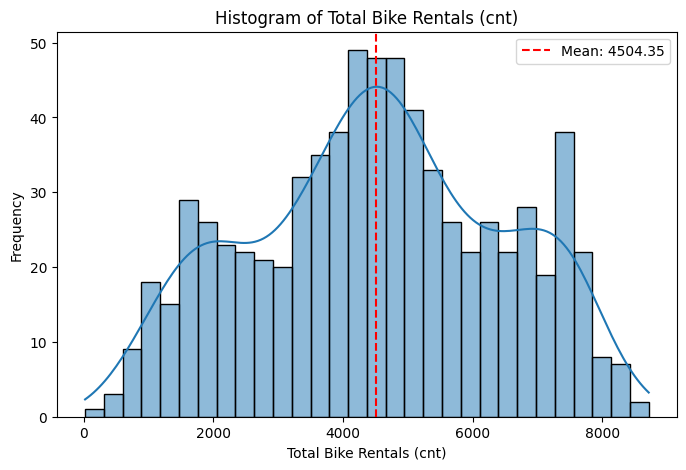


=== Summary Statistics of the 'cnt' Column. ===


,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df is defined.
if 'df' not in locals() and 'df' not in globals():
    df = pd.read_csv('bike_sharing.csv')

# Plot the histogram of the 'cnt' column.
plt.figure(figsize = (8, 5))
sns.histplot(df['cnt'], bins = 30, kde = True)
plt.title('Histogram of Total Bike Rentals (cnt)')
plt.xlabel('Total Bike Rentals (cnt)')
plt.ylabel('Frequency')

# Add vertical lines for mean and standard deviation.
mean_cnt = df['cnt'].mean()
std_cnt = df['cnt'].std()
plt.axvline(mean_cnt, color = 'red', linestyle = '--', label = f'Mean: {mean_cnt:.2f}')
plt.legend()
plt.show()

# Display the summary statistics of the 'cnt' column.
print("\n=== Summary Statistics of the 'cnt' Column. ===")
display(df['cnt'].describe())

## Phase 6 (Optional for Undergraduates) SVM Model
Train an SVM regressor with the `SVR` class from `sklearn`. Choose model settings carefully to optimize the model's performance. Compare the performance of the SVM model with the polynomial model.

Comparing the two models, the fine-tuned polynomial regression model significantly outperforms the SVM model on this dataset. The polynomial model achieved a Test RMSE of approximately 652.74, whereas the SVM model with its current parameters yielded a higher Test RMSE of 1034.90. Since a lower RMSE indicates that the model's predictions are closer to the actual bike rental counts, the polynomial model is currently the stronger and more accurate predictor.

In [15]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Create the SVM regression model.
svm_model = SVR(kernel = 'rbf', C = 100, gamma = 'scale')

# Train the SVM model on the training data.
svm_model.fit(X_train, y_train)

# Predict the target values for the test set.
y_svm_pred = svm_model.predict(X_test)

# Calculate the RMSE for the SVM model.
svm_rmse = np.sqrt(mean_squared_error(y_test, y_svm_pred))

# Display the RMSE of the SVM model.
print("=== SVM Model Test RMSE ===")
print(svm_rmse)

=== SVM Model Test RMSE ===
1034.9009055832266
